In [25]:
import requests
import pandas as pd

url = "https://aviationweather.gov/api/data/metar"
params = {
    "ids": "CYYZ,CYVR,CYUL,CYEG,CYYC,CYOW,CYWG,CYQB",
    "format": "json",
    "hours": 24
}
response = requests.get(url, params = params)
data = response.json()

df = pd.DataFrame(data)
print(df.shape)
print(df.columns)


(239, 23)
Index(['icaoId', 'receiptTime', 'obsTime', 'reportTime', 'temp', 'dewp',
       'wdir', 'wspd', 'visib', 'altim', 'slp', 'qcField', 'metarType',
       'rawOb', 'lat', 'lon', 'elev', 'name', 'cover', 'clouds', 'fltCat',
       'wgst', 'wxString'],
      dtype='str')


In [26]:
df['clouds'].head()

0    [{'cover': 'BKN', 'base': 17000}, {'cover': 'O...
1    [{'cover': 'SCT', 'base': 4000}, {'cover': 'BK...
2                     [{'cover': 'BKN', 'base': 4800}]
3    [{'cover': 'SCT', 'base': 3100}, {'cover': 'BK...
4    [{'cover': 'FEW', 'base': 5400}, {'cover': 'FE...
Name: clouds, dtype: object

In [27]:
def get_ceiling(clouds):
    ceiling_layers = [c['base'] for c in clouds if c['cover'] in ('BKN', 'OVC')]
    return min(ceiling_layers) if ceiling_layers else None

df['ceiling'] = df['clouds'].apply(get_ceiling)

In [28]:
df[['icaoId', 'clouds', 'ceiling']].head()

,icaoId,clouds,ceiling
0,CYQB,"[{'cover': 'BKN', 'base': 17000}, {'cover': 'O...",17000.0
1,CYEG,"[{'cover': 'SCT', 'base': 4000}, {'cover': 'BK...",9100.0
2,CYYZ,"[{'cover': 'BKN', 'base': 4800}]",4800.0
3,CYYC,"[{'cover': 'SCT', 'base': 3100}, {'cover': 'BK...",9800.0
4,CYWG,"[{'cover': 'FEW', 'base': 5400}, {'cover': 'FE...",NaN


In [29]:
df['temp_dewp_spread'] = df['temp'] - df['dewp']

In [30]:
features_to_use = df[['icaoId', 'visib', 'wspd', 'temp_dewp_spread', 'ceiling', 'fltCat']]
features_to_use

,icaoId,visib,wspd,temp_dewp_spread,ceiling,fltCat
0,CYQB,30,5,7,17000.0,VFR
1,CYEG,15,10,7,9100.0,VFR
2,CYYZ,15,16,11,4800.0,VFR
3,CYYC,8,8,6,9800.0,VFR
4,CYWG,15,26,10,NaN,VFR
...,...,...,...,...,...,...
234,CYYC,8,19,8,25000.0,VFR
235,CYOW,15,7,17,NaN,VFR
236,CYQB,20,8,12,28000.0,VFR
237,CYWG,15,16,4,20000.0,VFR


In [31]:
features_to_use['fltCat'].value_counts()

fltCat
VFR     214
MVFR     19
IFR       6
Name: count, dtype: int64

In [32]:
features_to_use['fltCat_binary'] = features_to_use['fltCat'].apply(lambda x: 'VFR' if x == 'VFR' else 'non-VFR')
features_to_use['fltCat_binary'].value_counts()

                                        

fltCat_binary
VFR        214
non-VFR     25
Name: count, dtype: int64

In [ ]:
features_to_use['fltCat_binary'].value_counts().plot(kind='bar')


In [33]:
features_to_use['visib'] = features_to_use['visib'].astype(str).str.replace('+', '', regex=False).astype(float)


<Axes: xlabel='ceiling', ylabel='visib'>

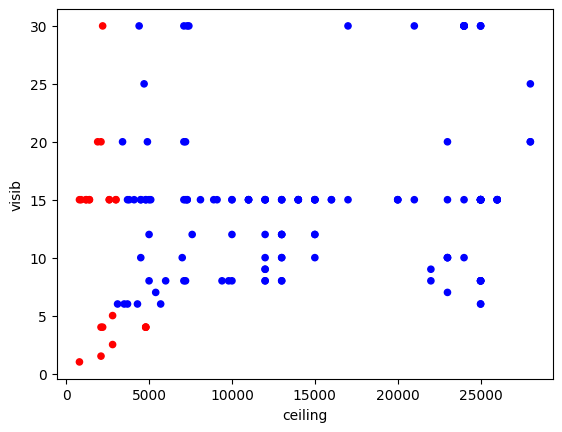

In [34]:
features_to_use.plot.scatter(x='ceiling', y='visib',
                c=features_to_use['fltCat_binary'].map(lambda x: 'red' if x == 'non-VFR' else 'blue'))
                

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = features_to_use[['visib', 'wspd', 'temp_dewp_spread', 'ceiling']]
y = features_to_use['fltCat_binary']

pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', RandomForestClassifier())
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(scores.mean())

0.987322695035461


In [37]:
import joblib

pipeline.fit(X, y)
joblib.dump(pipeline,'metar_classifier.pkl')

['metar_classifier.pkl']